In [2]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv(
    'rmsf_res.xvg',
    comment='@',
    delim_whitespace=True,
    header=None,
    names=['Time', 'RMSF'],
)

# Basic statistical analysis
mean_pe = data['RMSF'].mean()
print(f'Average RMSF: {mean_pe:.2f}')

# Plotting the energy trajectory
plt.plot(data['Time'], data['RMSF'])
plt.xlabel('Time (ps)')
plt.ylabel('RMSF')
plt.title('RMSF over Time')
plt.show()


/tmp/ipykernel_22542/391043776.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(


ParserError: Error tokenizing data. C error: Expected 10 fields in line 10, saw 13


In [3]:
import os
os.getcwd()

'/home/ann_hater/Documents/University/M2/Project files/02.Advanced_MD'

In [4]:
import numpy as np

def read_xvg(path):
    """Read a GROMACS .xvg file. Returns (data, meta)."""
    meta = {"title": "", "xaxis": "", "yaxis": "", "legends": []}
    rows = []
    with open(path) as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            if line.startswith("@"):
                if "xaxis" in line and '"' in line:
                    meta["xaxis"] = line.split('"')[1]
                elif "yaxis" in line and '"' in line:
                    meta["yaxis"] = line.split('"')[1]
                elif line.startswith("@ s") and "legend" in line:
                    meta["legends"].append(line.split('"')[1])
            continue
            rows.append([float(v) for v in line.split()])
    return np.array(rows), meta

In [5]:
def parse_gromacs_xvg(filename):
    """Reads a GROMACS .xvg file, ignoring metadata rows starting with @ or #."""
    with open(filename, 'r') as file:
        # Determine how many metadata rows to skip
        skip_count = sum(
            1 for line in file if line.startswith('@') or line.startswith('#')
        )

    # Load data rows into a DataFrame
    return pd.read_csv(
        filename, skiprows=skip_count, delim_whitespace=True, header=None
    )

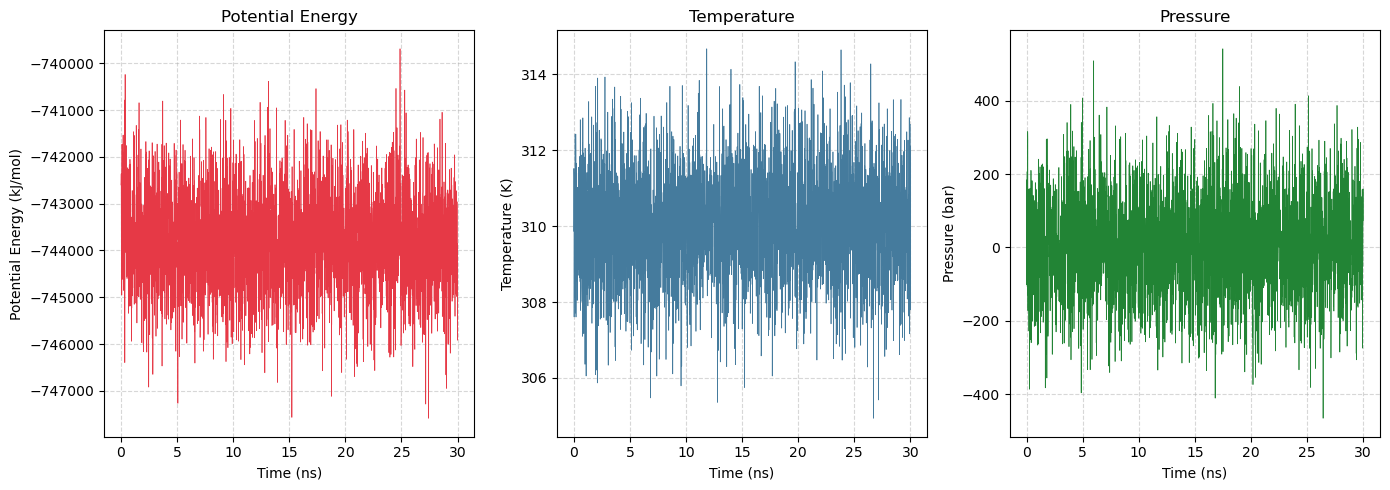

In [37]:
    # Construct the subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    # Left Plot: RMSD
    # Column 0: Frame/Time | Column 1: RMSD (nm)
    ax1.plot((df_energy.iloc[:, 0])/1000, df_energy.iloc[:, 1], color='#E63946', lw=0.5)
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Potential Energy (kJ/mol)')
    ax1.set_title('Potential Energy')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right Plot: Temperature
    # Column 0: Atom/Residue ID | Column 1: RMSF (nm)
    ax2.plot((df_energy.iloc[:, 0])/1000, df_energy.iloc[:, 2], color='#457B9D', lw=0.5)
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Temperature (K)')
    ax2.set_title('Temperature')
    ax2.grid(True, linestyle='--', alpha=0.5)


    # Right Plot: Pressure
    # Column 0: Atom/Residue ID | Column 1: RMSF (nm)
    ax3.plot((df_energy.iloc[:, 0])/1000, df_energy.iloc[:, 3], color="#228435", lw=0.5)
    ax3.set_xlabel('Time (ns)')
    ax3.set_ylabel('Pressure (bar)')
    ax3.set_title('Pressure')
    ax3.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [87]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
from MDAnalysis.transformations import unwrap

# tpr carries bond connectivity, required for unwrap()
u = mda.Universe('md_100.tpr', 'md_100_center.xtc')
#ref = mda.Universe('md_100.tpr', '1G5J.gro')  # or a first-frame reference

# Unwrap the whole system so no molecule is split across a box edge
u.trajectory.add_transformations(unwrap(u.atoms))


# Fit and report receptor and peptide separately — don't mix them
R = rms.RMSD(
    u,
    select='protein and name CA and chainID A',       # fit on receptor only — adjust segid
    groupselections=[
        'protein and chainID A',   # Bcl-XL RMSD
        'protein and chainID B',   # BAD peptide RMSD, same fit applied
    ],
)
R.run()

In [85]:
print(u.segments)                         # segids, if any
print(sorted(set(u.residues.resids)))      # actual resid values present
print(set(u.atoms.chainIDs)) if hasattr(u.atoms, 'chainIDs') else None

<SegmentGroup [<Segment seg_0_Protein_chain_A>, <Segment seg_1_Protein_chain_B>, <Segment seg_2_SOL>, <Segment seg_3_NA>]>
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.

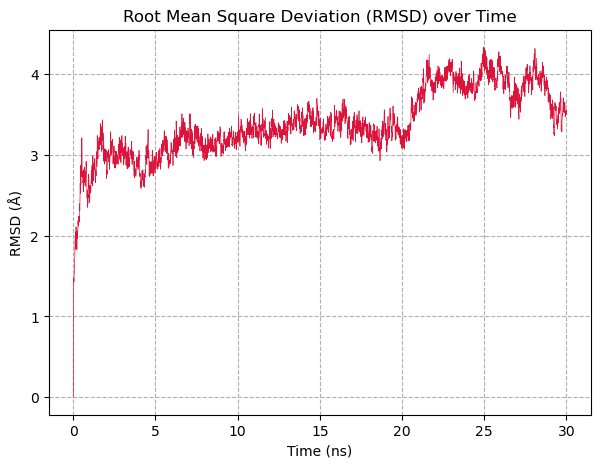

In [95]:
rmsd_data = R.results.rmsd 
# =====================================================================
# 4. Plotting the Results
# =====================================================================
fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

# Plot RMSD over Time
ax1.plot(rmsd_data[:, 1] / 1000, rmsd_data[:, 3], color='crimson', label='Protein', linewidth=0.5)
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('RMSD (Å)')
ax1.set_title('Root Mean Square Deviation (RMSD) over Time')
ax1.grid(True, linestyle='--')


In [17]:
df_energy = parse_gromacs_xvg("thermodynamics.xvg")

/tmp/ipykernel_57477/1289778620.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(


/tmp/ipykernel_22542/1289778620.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(
/tmp/ipykernel_22542/1289778620.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(


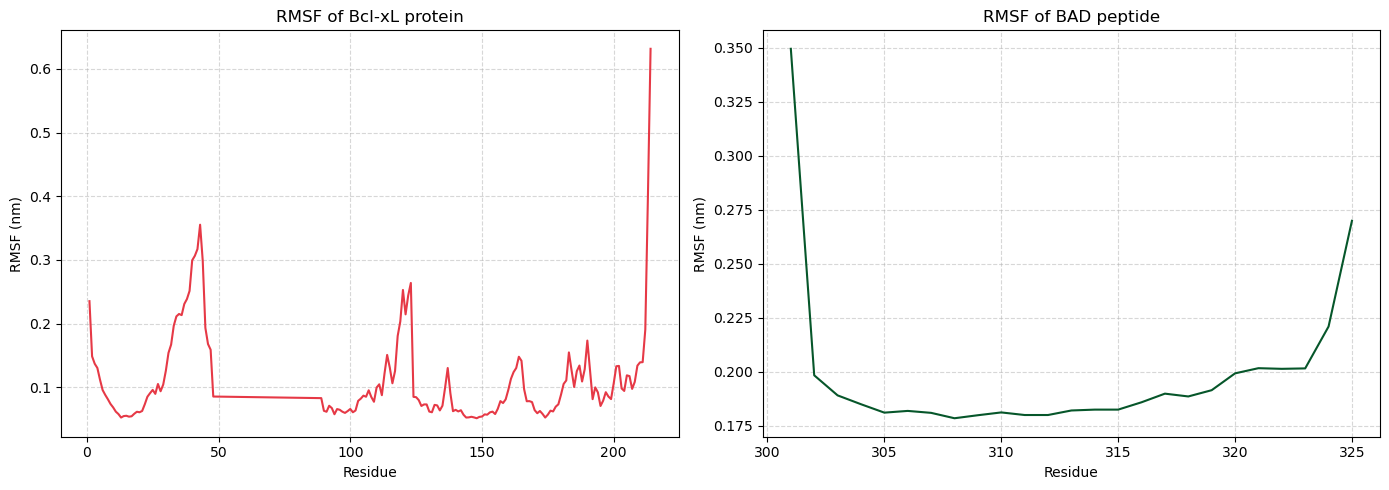

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets
try:
    df_rmsd = parse_gromacs_xvg('rmsd_30ns.xvg')
    df_rmsd.drop(df_rmsd.tail(6).index,inplace=True)
    df_rmsf = parse_gromacs_xvg('rmsf_res.xvg')
    #df_rmsf.drop(df_rmsf.tail(25).index,inplace=True)
    # df_rmsf = df_rmsf.iloc[0:47]
    # Construct the subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # # Left Plot: RMSD
    # # Column 0: Frame/Time | Column 1: RMSD (nm)
    # ax1.plot(df_rmsd.iloc[:, 0], df_rmsd.iloc[:, 1], color='#E63946', lw=1.5)
    # ax1.set_xlabel('Frame / Time')
    # ax1.set_ylabel('RMSD (nm)')
    # ax1.set_title('Root Mean Square Deviation (RMSD)')
    # ax1.grid(True, linestyle='--', alpha=0.5)

    ax1.plot(df_rmsf.iloc[0:174, 0], df_rmsf.iloc[0:174, 1], color='#E63946', lw=1.5)
    ax1.set_xlabel('Residue')
    ax1.set_ylabel('RMSF (nm)')
    ax1.set_title('RMSF of Bcl-xL protein')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right Plot: RMSF
    # Column 0: Atom/Residue ID | Column 1: RMSF (nm)
    ax2.plot(df_rmsf.iloc[175:, 0], df_rmsf.iloc[175:, 1], color="#06562A", lw=1.5)
    ax2.set_xlabel('Residue')
    ax2.set_ylabel('RMSF (nm)')
    ax2.set_title('RMSF of BAD peptide')
    ax2.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(
        f"Missing file error: {e}. Ensure you ran the GROMACS 'gmx' commands first to generate the .xvg files."
    )


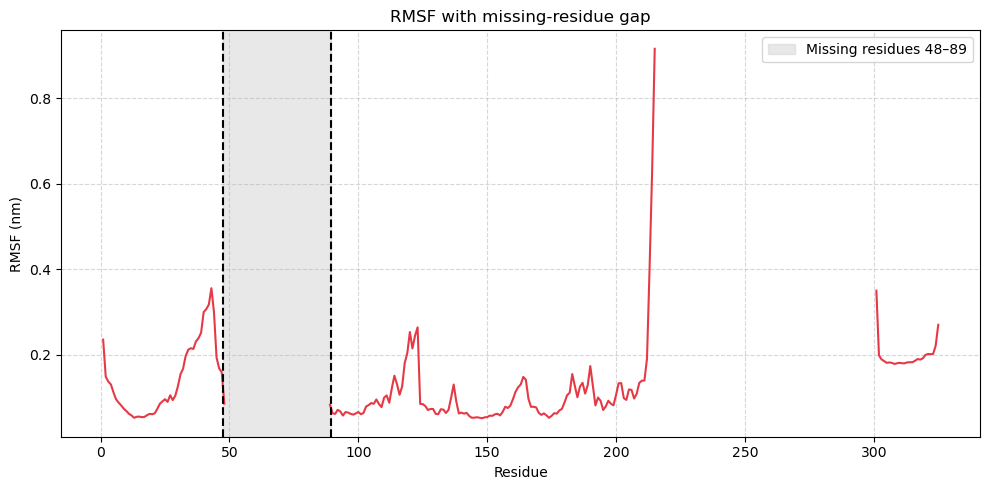

In [ ]:
# Copy residue number and RMSF columns
rmsf = df_rmsf.iloc[:, :2].copy()
rmsf.columns = ["Residue", "RMSF"]

# Ensure numeric residue IDs and remove duplicate residues
rmsf["Residue"] = pd.to_numeric(rmsf["Residue"], errors="coerce").astype("Int64")
rmsf["RMSF"] = pd.to_numeric(rmsf["RMSF"], errors="coerce")
rmsf = rmsf.dropna(subset=["Residue"]).drop_duplicates("Residue")

# Reindex using every residue number
residue_range = range(
    int(rmsf["Residue"].min()),
    int(rmsf["Residue"].max()) + 1
)

df_rmsf_reindexed = (
    rmsf.set_index("Residue")
        .reindex(residue_range)
)
df_rmsf_reindexed.index.name = "Residue"

# Plot: NaN values create a visible line break
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(
    df_rmsf_reindexed.iloc[0:174, 0],
    df_rmsf_reindexed.iloc[0:174,"RMSF"],
    color="#E63946",
    linewidth=1.5
)
ax1.set_xlabel('Residue')
ax1.set_ylabel('RMSF (nm)')
ax1.set_title('RMSF of Bcl-xL protein')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(
    df_rmsf_reindexed.iloc[175:, 0],
    df_rmsf_reindexed.iloc[175:,"RMSF"],
    color="#06562A",
    linewidth=1.5
)
ax2.set_xlabel('Residue')
ax2.set_ylabel('RMSF (nm)')
ax2.set_title('RMSF of BAD peptide')
ax2.grid(True, linestyle='--', alpha=0.5)

# Highlight the missing-residue gap
gap_start, gap_end = 48, 89

ax.axvspan(
    gap_start - 0.5,
    gap_end + 0.5,
    color="lightgray",
    alpha=90,
    label=f"Missing residues {gap_start}–{gap_end}"
)

# Borders surrounding the gap
ax.axvline(gap_start - 0.5, color="black", linestyle="--")
ax.axvline(gap_end + 0.5, color="black", linestyle="--")

ax.set_xlabel("Residue")
ax.set_ylabel("RMSF (nm)")
ax.set_title("RMSF with missing-residue gap")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_rmsf_new = pd.DataFrame()
for residue in list(range(1,200)):
    if residue in list(df_rmsf.iloc[:,0]):
        df_rmsf_new.[residue, 1] = df_rmsf.iat[residue, 1]
    else:
        df_rmsf_new.iat[residue, 1] = None

IndexError: index 1 is out of bounds for axis 0 with size 0

In [52]:
df_rmsf[df_rmsf[0]]
# list(df_rmsf.iloc[:,0])

KeyError: '[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325] not in index'